## Lab Assignment: Exploring KNN and RNN Classifiers
**Course:** Advanced Big Data and Data Mining  
**Name:** Hoai Nam Tran 

---
### Step 1: Load Data and Prepare the Dataset

In [20]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [17]:
# Load the wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Basic data exploration
print('=== Wine Dataset Overview ===')
print(f'Number of samples: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print(f'Feature names: {wine.feature_names}')
print(f'Class names: {wine.target_names}')

print('\n=== Class Distribution ===')
unique, counts = np.unique(y, return_counts= True)
for cls, count in zip(wine.target_names, counts):
    print(f' {cls}: {count} samples')

# Display as a DataFrame
df = pd.DataFrame(X, columns= wine.feature_names)
df['class'] = y
print('=== First 5 rows ===')
df.head()

=== Wine Dataset Overview ===
Number of samples: 178
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Class names: ['class_0' 'class_1' 'class_2']

=== Class Distribution ===
 class_0: 59 samples
 class_1: 71 samples
 class_2: 48 samples
=== First 5 rows ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
# Basic Statistics
print('=== Feature Statistics ===')
df.drop(columns= 'class').describe().round(2)

=== Feature Statistics ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [21]:
# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

print('=== Train/Test Split ===')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

# Apply StandardScaler AFTER splitting
# Fit on training data only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print('\n=== StandardScaler Applied ===')
print(f'Training set mean (should be ~0): {X_train_scaled.mean(axis=0).round(2)}')
print(f'Training set std  (should be ~1): {X_train_scaled.std(axis=0).round(2)}')

=== Train/Test Split ===
Training samples: 142
Testing samples: 36

=== StandardScaler Applied ===
Training set mean (should be ~0): [ 0. -0.  0.  0. -0.  0.  0. -0.  0.  0.  0.  0. -0.]
Training set std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
### Step 2: Implement K-Nearest Neighbors (KNN)

In [22]:
# Define k values to test
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

print('=== KNN Classifier Results (Scaled Data) ===')
print(f'{"k":>4}  {"Accuracy":>10}')
print('-' * 18)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f'{k:>4}  {acc:>9.4f}')

print(f'\nBest k: {k_values[np.argmax(knn_accuracies)]}  '
      f'(Accuracy: {max(knn_accuracies):.4f})')

=== KNN Classifier Results (Scaled Data) ===
   k    Accuracy
------------------
   1     0.9444
   5     0.9444
  11     0.9444
  15     0.9722
  21     0.9444

Best k: 15  (Accuracy: 0.9722)


---
### Step 3: Implement Radius Neighbors (RNN)

In [23]:
# After scaling, features are in a much smaller range (~-3 to +3)
# so radius values are also much smaller
radius_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
rnn_accuracies = []

print('=== Radius Neighbors Classifier Results (Scaled Data) ===')
print(f'{"Radius":>8}  {"Accuracy":>10}  Outliers')
print('-' * 35)

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label=-1)
    rnn.fit(X_train_scaled, y_train)
    y_pred = rnn.predict(X_test_scaled)

    mask = y_pred != -1
    acc = accuracy_score(y_test[mask], y_pred[mask]) if mask.sum() > 0 else 0.0
    rnn_accuracies.append(acc)

    outliers = (~mask).sum()
    print(f'{r:>8.1f}  {acc:>9.4f}  {outliers}')

print(f'\nBest radius: {radius_values[np.argmax(rnn_accuracies)]}  '
      f'(Accuracy: {max(rnn_accuracies):.4f})')

=== Radius Neighbors Classifier Results (Scaled Data) ===
  Radius    Accuracy  Outliers
-----------------------------------
     1.0     0.0000  36
     1.5     1.0000  23
     2.0     1.0000  7
     2.5     0.9714  1
     3.0     0.9444  0
     3.5     0.9722  0

Best radius: 1.5  (Accuracy: 1.0000)


C:\Users\nam.tran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:864: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
C:\Users\nam.tran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:864: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
C:\Users\nam.tran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:864: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
C:\Users\nam.tran\AppData\Local\Packages

---
### Step 4: Visualize and Compare Results

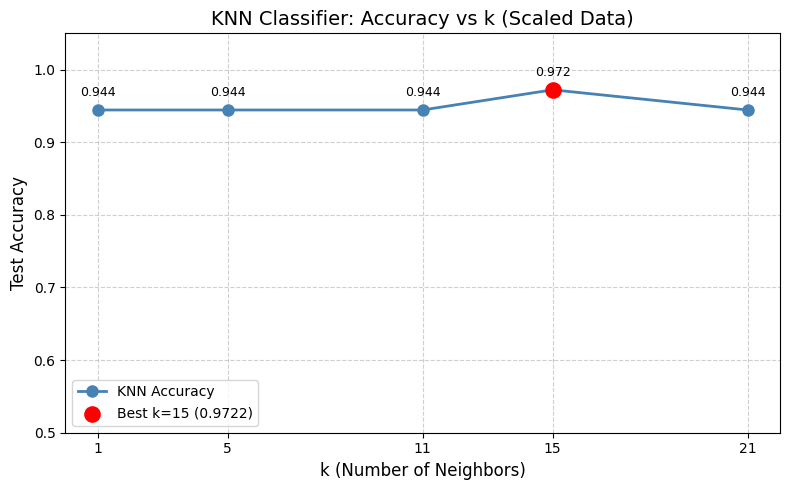

In [25]:
# Plot 1: KNN Accuracy vs k
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, knn_accuracies, marker='o', linewidth=2,
        color='steelblue', markersize=8, label='KNN Accuracy')

best_k_idx = np.argmax(knn_accuracies)
ax.scatter(k_values[best_k_idx], knn_accuracies[best_k_idx],
           color='red', zorder=5, s=120,
           label=f'Best k={k_values[best_k_idx]} ({knn_accuracies[best_k_idx]:.4f})')

for k, acc in zip(k_values, knn_accuracies):
    ax.annotate(f'{acc:.3f}', (k, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9)

ax.set_title('KNN Classifier: Accuracy vs k (Scaled Data)', fontsize=14)
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_xticks(k_values)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('knn_accuracy.png', dpi=150)
plt.show()

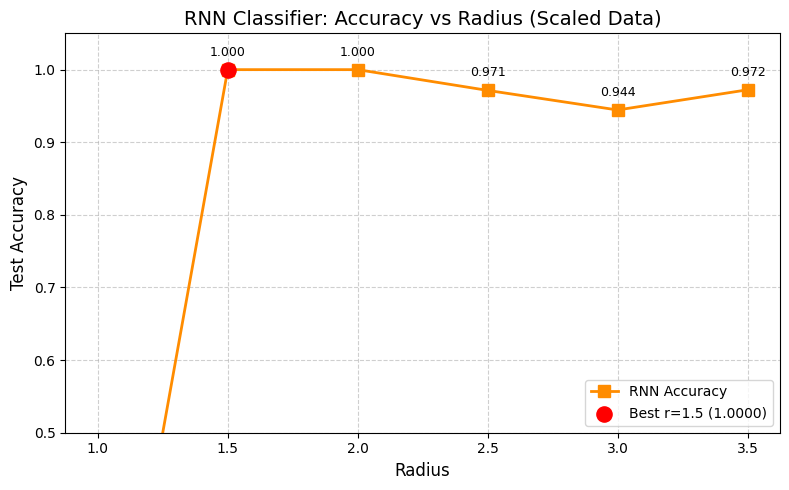

In [26]:
# Plot 2: RNN Accuracy vs Radius
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(radius_values, rnn_accuracies, marker='s', linewidth=2,
        color='darkorange', markersize=8, label='RNN Accuracy')

best_r_idx = np.argmax(rnn_accuracies)
ax.scatter(radius_values[best_r_idx], rnn_accuracies[best_r_idx],
           color='red', zorder=5, s=120,
           label=f'Best r={radius_values[best_r_idx]} ({rnn_accuracies[best_r_idx]:.4f})')

for r, acc in zip(radius_values, rnn_accuracies):
    ax.annotate(f'{acc:.3f}', (r, acc),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9)

ax.set_title('RNN Classifier: Accuracy vs Radius (Scaled Data)', fontsize=14)
ax.set_xlabel('Radius', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_xticks(radius_values)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rnn_accuracy.png', dpi=150)
plt.show()

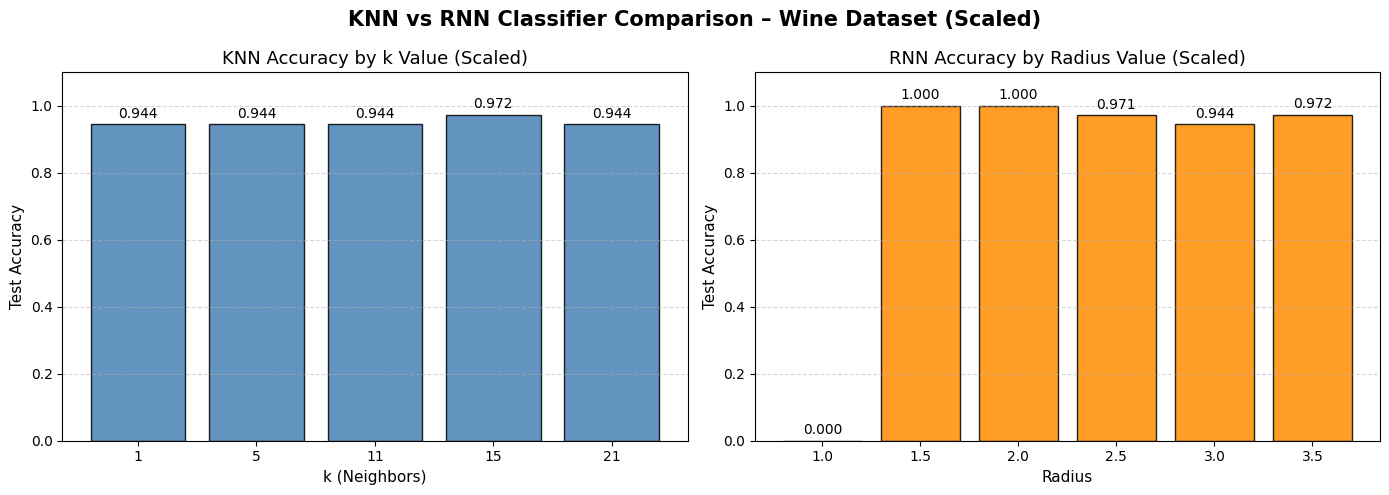

In [27]:
# Plot 3: Side-by-side bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(k) for k in k_values], knn_accuracies,
            color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('KNN Accuracy by k Value (Scaled)', fontsize=13)
axes[0].set_xlabel('k (Neighbors)', fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_ylim(0, 1.1)
for i, acc in enumerate(knn_accuracies):
    axes[0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar([str(r) for r in radius_values], rnn_accuracies,
            color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_title('RNN Accuracy by Radius Value (Scaled)', fontsize=13)
axes[1].set_xlabel('Radius', fontsize=11)
axes[1].set_ylabel('Test Accuracy', fontsize=11)
axes[1].set_ylim(0, 1.1)
for i, acc in enumerate(rnn_accuracies):
    axes[1].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('KNN vs RNN Classifier Comparison – Wine Dataset (Scaled)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

---
### Analysis and Discussion

### Effect of StandardScaler
Applying `StandardScaler` transforms all features to have mean=0 and std=1. This is critical for distance-based models like KNN and RNN because features with large raw values (e.g., proline ~300–1700) would otherwise dominate distance calculations over features with small values (e.g., alcohol ~11–14). After scaling, all features contribute equally to the distance metric, which significantly improves classification accuracy.


### KNN Results
- With scaled data, KNN accuracy improves noticeably compared to unscaled results.
- Smaller k values may still overfit, while larger k values provide smoother boundaries.
- The best k balances local sensitivity with generalization.

### RNN Results
- After scaling, meaningful radius values shift to a much smaller range (~1.0–3.5) since all features now have comparable magnitude.
- Smaller radii may still produce outlier points with no neighbors; larger radii capture too many neighbors.

### KNN vs RNN: When to Use Each?

| Criterion | KNN | RNN |
|-----------|-----|-----|
| **Consistency** | Always classifies every point | May leave outlier points unclassified |
| **Parameter meaning** | Fixed number of neighbors | Fixed spatial distance |
| **Density sensitivity** | Less sensitive | More sensitive to sparse regions |
| **Best when…** | Uniform data density | Varying cluster density |

**Prefer KNN** when you need reliable predictions for every test point.  
**Prefer RNN** when the data has naturally varying density and you have domain knowledge to choose a meaningful distance threshold.